In [1]:
import os
from IPython.display import display, Image

from Hyperparameter_Tuning.extended_hyperparameter_tuning import config, build_tunable_model
from Hyperparameter_Tuning.tuning_core import run_tuning

# Tuning the Hyperparameters
This notebook shows how to tune the hyperparameters of the LAND model by adjusting the configurations and running the hyperparameter tuning script.

In [ ]:
# Set the configuration for hyperparameter tuning
cfg = config(
    npz_path=os.path.join('ML_Data_Preprocessing', 'output', 'assembled_npz', 'full_training_data.npz'),
    test_indices_path=os.path.join('Hyperparameter_Tuning', 'output', 'test_indices.pkl'),
    output_dir=os.path.join('Hyperparameter_Tuning', 'output'),
    max_trials=150,
    executions_per_trial=1,
    epochs=150,
    # batch_size=64,
    n_folds=10,
    cv_seed=42,
    resume=True,
)

In [3]:
# Run the hyperparameter tuning 
run_tuning(config=cfg, build_model_fn=build_tunable_model, patience=30)

Loading assembled NPZ from ML_Data_Preprocessing/output/assembled_npz/full_training_data.npz...
CV pool sizes:
  N_cv = 1828
  climate: (1828, 16, 3, 3)
  local_dem: (1828, 3, 3)
  regional_dem: (1828, 3, 3)
  month: (1828, 12)
  targets: (1828,)
Reloading Tuner from Hyperparameter_Tuning/output/land_model_cv_tuning/tuner0.json

Resuming from previous tuning session...
Found 150 completed trials
Best val_loss so far: 0.192492
Best hyperparameters so far:
  na: 64
  nb: 128
  dropout_rate: 0.5
  l2_reg: 1e-06
  learning_rate: 0.0001
  weight_decay: 1e-07
  batch_size: 64
  local_dem_units: 256
  regional_dem_units: 32
  month_units: 16
  climate_units: 512
  use_residual: False
  activation: relu
  output_activation: softplus

Starting extended hyperparameter tuning with cross-validation...
Resuming with 0 remaining trials of 150 total
Each fold will train for up to 150 epochs
Best hyperparameters will be saved after each trial to 'land_model_cv_tuning/current_best_hyperparameters.py'



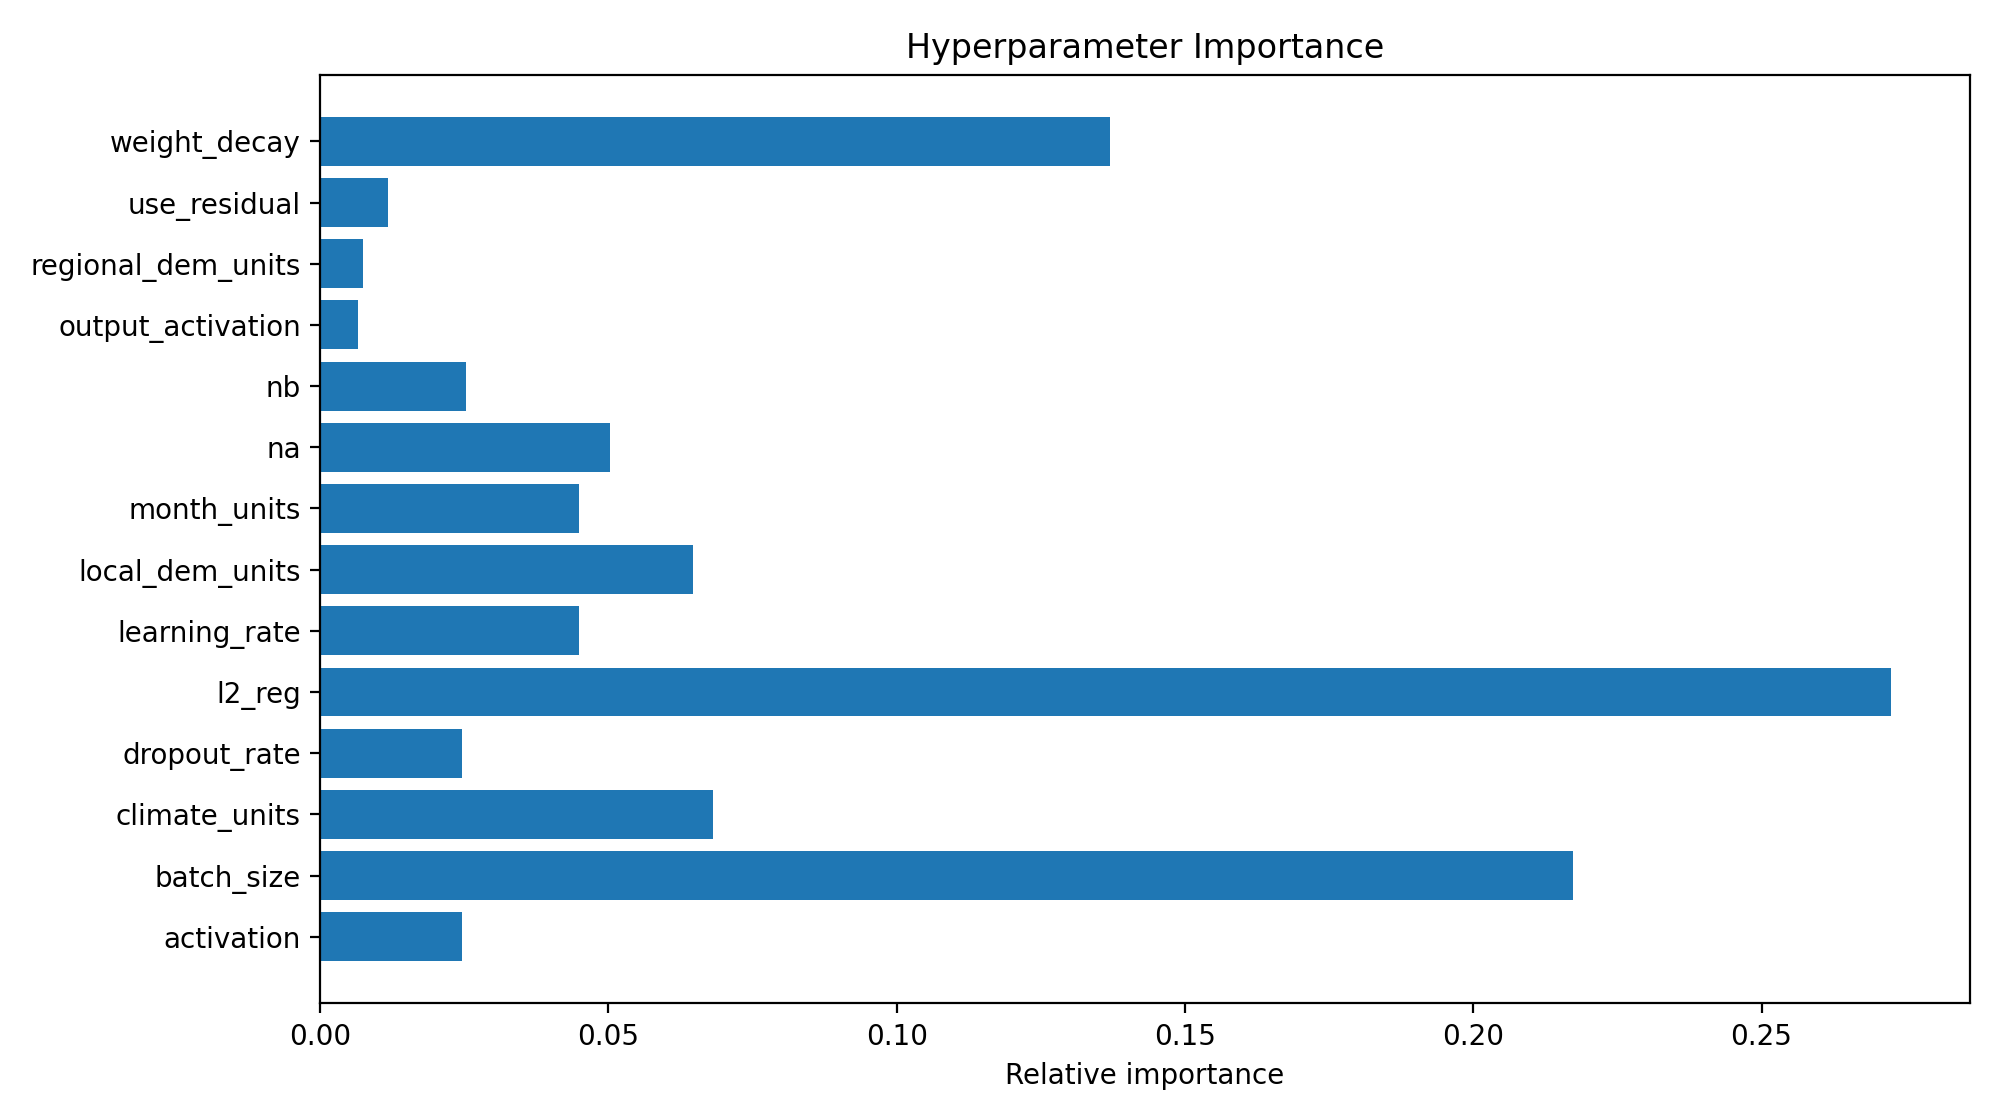

In [4]:
# Set ensemble visualization path
hp_importance_viz_path = os.path.join(cfg['output_dir'], 'hyperparameter_importance.png')
# Load the test predictions visualization
hp_importance_viz = display(Image(filename=hp_importance_viz_path))